# Explicaciones SHAP de un clasificador de imágenes preentrenado (DeiT)

Josué Emanuel Say García (22801) · Gustavo Adolfo Cruz Bardales (22779)

**Entrada.** Clasificador preentrenado `facebook/deit-small-patch16-224` (ImageNet-1k),
3 imágenes de prueba, y una pregunta explicativa concreta.

**Pregunta explicativa.** ¿En qué regiones de la imagen se apoya DeiT para asignar su
etiqueta: en el cuerpo del animal o en el contexto acuático de la escena?

Corre en Google Colab o en local. Tiempo aproximado: 8 minutos en CPU.

## 1. Dependencias

In [1]:
import importlib, subprocess, sys
for mod, pkg in [("transformers", "transformers"), ("shap", "shap"),
                 ("cv2", "opencv-python-headless")]:
    if importlib.util.find_spec(mod) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)

import json, os, urllib.request
import matplotlib.pyplot as plt
import numpy as np, shap, torch
from PIL import Image
from transformers import AutoModelForImageClassification

torch.manual_seed(42); np.random.seed(42)
os.makedirs("figures", exist_ok=True)
print("shap", shap.__version__, "| torch", torch.__version__)

/nix/store/m53qzwrbrya4c8khgf12awj6z3dhjw2p-python3-3.13.13-env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


shap 0.50.0 | torch 2.12.0


## 2. Las tres imágenes de prueba

Se descargan por URL directa, con su licencia y autoría.

| ID | Contenido | Fuente | Licencia |
|---|---|---|---|
| IMG-01 | capibara sobre tierra seca | `freds0/capybara_dataset` | MIT |
| IMG-02 | castor nadando | iNaturalist, foto 725021665 | CC BY-NC, © Kevin Harrison |
| IMG-03 | capibara en la orilla de un río | iNaturalist, foto 721783385 | CC BY-NC |

IMG-01 e IMG-03 son la misma especie en contextos opuestos (seco / acuático); IMG-02 es la
otra especie en contexto acuático. El contraste permite separar «el modelo mira al animal»
de «el modelo mira el agua».

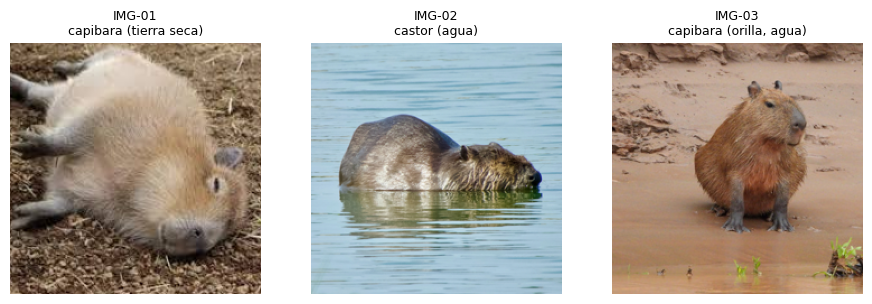

In [2]:
IMGS = [
    ("IMG-01", "capibara (tierra seca)",
     "https://raw.githubusercontent.com/freds0/capybara_dataset/main/images/test/186.jpeg"),
    ("IMG-02", "castor (agua)",
     "https://inaturalist-open-data.s3.amazonaws.com/photos/725021665/medium.jpg"),
    ("IMG-03", "capibara (orilla, agua)",
     "https://inaturalist-open-data.s3.amazonaws.com/photos/721783385/medium.jpg"),
]
UA = {"User-Agent": "proyecto-academico-shap/1.0"}

def load224(iid, url):
    fn = f"img_{iid}.jpg"
    if not os.path.exists(fn):
        req = urllib.request.Request(url, headers=UA)
        with urllib.request.urlopen(req, timeout=60) as r, open(fn, "wb") as f:
            f.write(r.read())
    im = Image.open(fn).convert("RGB")
    w, h = im.size; s = 256 / min(w, h)
    im = im.resize((round(w * s), round(h * s)), Image.BICUBIC)
    l, t = (im.width - 224) // 2, (im.height - 224) // 2
    return np.array(im.crop((l, t, l + 224, t + 224)), dtype=np.uint8)

X = np.stack([load224(i, u) for i, _, u in IMGS])
fig, ax = plt.subplots(1, 3, figsize=(11, 4))
for a, x, (i, d, _) in zip(ax, X, IMGS):
    a.imshow(x); a.set_title(f"{i}\n{d}", fontsize=9); a.axis("off")
fig.savefig("figures/entradas.png", dpi=150, bbox_inches="tight"); plt.show()

## 3. Modelo

`facebook/deit-small-patch16-224`: Vision Transformer de ~22M parámetros preentrenado en
ImageNet-1k. **No se entrena nada**: se usa tal cual, con sus 1000 clases originales.

Detalle relevante para leer los resultados: ImageNet-1k contiene la clase `beaver`
(índice 337) pero **no** contiene `capybara`. El modelo no tiene vocabulario para nombrar
una capibara, así que para IMG-01 e IMG-03 devolverá necesariamente una etiqueta incorrecta.
Lo que nos interesa no es el acierto, sino en qué regiones se apoya.

In [3]:
CK = "facebook/deit-small-patch16-224"
model = AutoModelForImageClassification.from_pretrained(CK).eval()
id2label = model.config.id2label
class_names = [id2label[i] for i in range(len(id2label))]

def predict(imgs):
    x = torch.from_numpy(imgs.astype(np.float32) / 255.0).permute(0, 3, 1, 2)
    x = (x - 0.5) / 0.5
    with torch.no_grad():
        return torch.softmax(model(pixel_values=x).logits, -1).numpy()

probs = predict(X)
R = {"checkpoint": CK, "imagenes": []}
for k, (iid, desc, url) in enumerate(IMGS):
    top = probs[k].argsort()[::-1][:3]
    R["imagenes"].append({
        "id": iid, "descripcion": desc, "url": url,
        "top1": class_names[top[0]], "p_top1": float(probs[k][top[0]]),
        "top3": [[class_names[t], round(float(probs[k][t]), 4)] for t in top],
        "p_beaver": float(probs[k][337]),
    })
    print(f"{iid} ({desc})")
    for t in top:
        print(f"    {class_names[t]:<28s} {probs[k][t]:.3f}")
    print(f"    [clase beaver=337]           {probs[k][337]:.3f}\n")

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 200/200 [00:00<00:00, 27670.56it/s]

IMG-01 (capibara (tierra seca))
    hog, pig, grunter, squealer, Sus scrofa 0.130
    beaver                       0.072
    wild boar, boar, Sus scrofa  0.071
    [clase beaver=337]           0.072

IMG-02 (castor (agua))
    beaver                       0.259
    leafhopper                   0.026
    lacewing, lacewing fly       0.025
    [clase beaver=337]           0.259

IMG-03 (capibara (orilla, agua))
    beaver                       0.498
    American coot, marsh hen, mud hen, water hen, Fulica americana 0.020
    dowitcher                    0.012
    [clase beaver=337]           0.498



## 4. SHAP

DeiT es un Vision Transformer, no una CNN, así que `DeepExplainer` y `GradientExplainer`
—que asumen capas convolucionales— no aplican. Usamos el explicador model-agnóstico
`shap.Explainer` con `shap.maskers.Image` (algoritmo *Partition*): trata el modelo como caja
negra, perturba regiones y mide el cambio en la probabilidad.

El *baseline* de enmascarado es la imagen desenfocada (`blur(128,128)`), no un parche gris,
para no introducir estructura fuera de distribución. La elección del baseline cambia los
valores de Shapley: no es un detalle cosmético.

**Criterio de lectura, fijado antes de ver los mapas.** Hay evidencia de que el modelo *mira
al animal* si la atribución positiva a la clase predicha se concentra sobre el cuerpo o la
cabeza; de que *mira al contexto* si cae sobre regiones de agua o vegetación sin animal. Un
resultado mixto se reporta como mixto.

  0%|          | 0/1998 [00:00<?, ?it/s]

 15%|█▍        | 298/1998 [00:02<00:13, 128.70it/s]

 18%|█▊        | 362/1998 [00:04<00:25, 64.78it/s] 

 21%|██▏       | 426/1998 [00:06<00:29, 54.14it/s]

 25%|██▍       | 490/1998 [00:08<00:33, 44.50it/s]

...

 98%|█████████▊| 1962/1998 [00:59<00:01, 32.35it/s]

2026it [01:01, 31.51it/s]                          

2062it [01:02, 31.74it/s]

PartitionExplainer explainer: 100%|██████████| 1/1 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [01:09, 69.87s/it]               

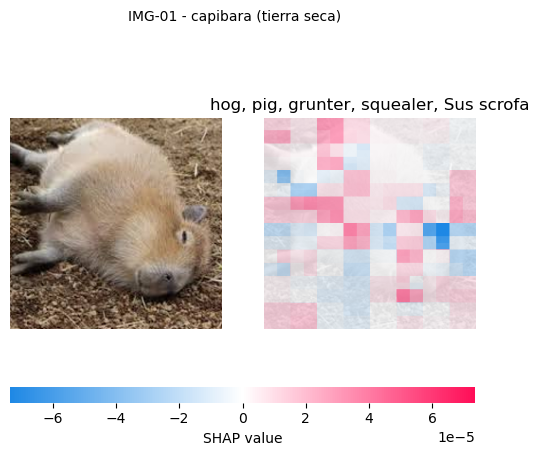

  0%|          | 0/1998 [00:00<?, ?it/s]

 15%|█▍        | 298/1998 [00:01<00:10, 163.70it/s]

 18%|█▊        | 362/1998 [00:03<00:19, 84.37it/s] 

 21%|██▏       | 426/1998 [00:05<00:25, 61.63it/s]

 25%|██▍       | 490/1998 [00:07<00:29, 51.22it/s]

...

 98%|█████████▊| 1962/1998 [00:51<00:01, 32.88it/s]

2026it [00:53, 33.08it/s]                          

2062it [00:54, 33.18it/s]

PartitionExplainer explainer: 100%|██████████| 1/1 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:59, 59.85s/it]               

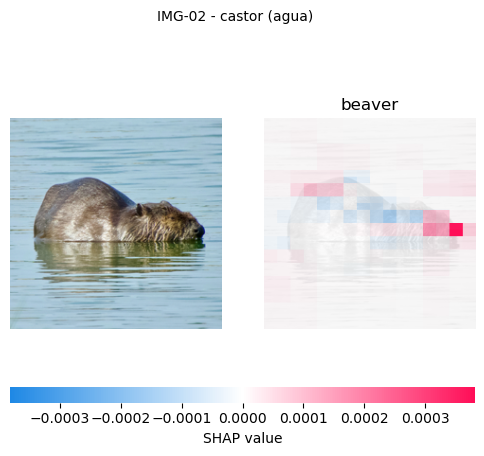

  0%|          | 0/1998 [00:00<?, ?it/s]

 18%|█▊        | 362/1998 [00:01<00:07, 208.72it/s]

 21%|██▏       | 426/1998 [00:03<00:16, 97.14it/s] 

 25%|██▍       | 490/1998 [00:05<00:21, 68.91it/s]

 28%|██▊       | 554/1998 [00:07<00:25, 57.36it/s]

...

 98%|█████████▊| 1962/1998 [00:51<00:01, 27.47it/s]

2026it [00:54, 27.29it/s]                          

2062it [00:55, 27.86it/s]

PartitionExplainer explainer: 100%|██████████| 1/1 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [01:01, 61.80s/it]               

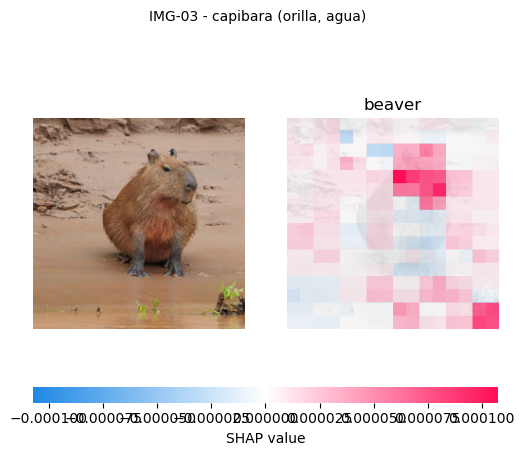

In [4]:
masker = shap.maskers.Image("blur(128,128)", X[0].shape)
explainer = shap.Explainer(predict, masker, output_names=class_names)

for k, (iid, desc, _) in enumerate(IMGS):
    sv = explainer(X[k:k + 1], max_evals=2000, batch_size=64,
                   outputs=shap.Explanation.argsort.flip[:1])
    shap.image_plot(sv, show=False)
    f = plt.gcf(); f.suptitle(f"{iid} - {desc}", fontsize=10)
    f.savefig(f"figures/shap_{iid.lower()}.png", dpi=150, bbox_inches="tight"); plt.show()

## 5. Estabilidad

*Partition* es una aproximación con presupuesto finito: sin comprobarlo no se puede afirmar
que una región «importa». Repetimos IMG-02 con tres presupuestos y correlacionamos los
mapas.

  0%|          | 0/998 [00:00<?, ?it/s]

 36%|███▋      | 362/998 [00:02<00:03, 159.53it/s]

 43%|████▎     | 426/998 [00:04<00:06, 85.51it/s] 

 49%|████▉     | 490/998 [00:06<00:08, 59.41it/s]

 56%|█████▌    | 554/998 [00:08<00:08, 52.71it/s]

...

4010it [01:47, 32.33it/s]                          

4062it [01:49, 32.79it/s]

PartitionExplainer explainer: 100%|██████████| 1/1 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [01:55, 115.36s/it]              

correlacion de Pearson entre mapas: {'1000_vs_2000': 0.9314, '1000_vs_4000': 0.8724, '2000_vs_4000': 0.9792}


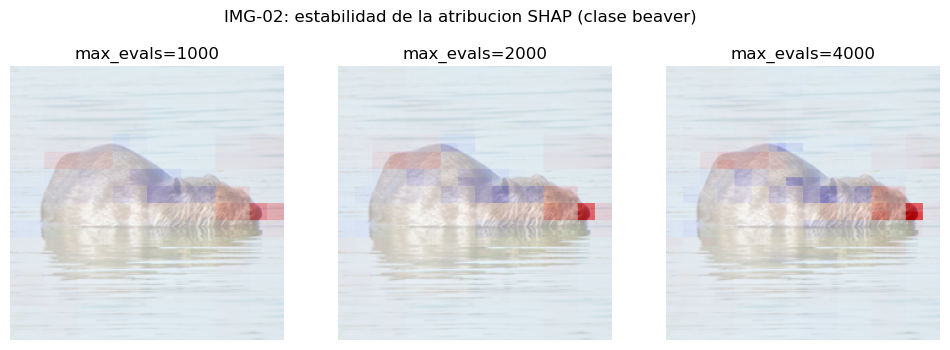


resultados -> results.json


In [5]:
stab = []
for b in [1000, 2000, 4000]:
    sv = explainer(X[1:2], max_evals=b, batch_size=64, outputs=[337])
    stab.append((b, np.array(sv.values)[0, ..., 0].sum(-1)))

corr = {f"{stab[i][0]}_vs_{stab[j][0]}":
        round(float(np.corrcoef(stab[i][1].ravel(), stab[j][1].ravel())[0, 1]), 4)
        for i in range(3) for j in range(i + 1, 3)}
R["estabilidad_pearson"] = corr
print("correlacion de Pearson entre mapas:", corr)

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
lim = max(np.abs(v).max() for _, v in stab)
for a, (b, v) in zip(ax, stab):
    a.imshow(X[1]); a.imshow(v, cmap="bwr", vmin=-lim, vmax=lim, alpha=0.65)
    a.set_title(f"max_evals={b}"); a.axis("off")
fig.suptitle("IMG-02: estabilidad de la atribucion SHAP (clase beaver)")
fig.savefig("figures/estabilidad.png", dpi=150, bbox_inches="tight"); plt.show()

json.dump(R, open("results.json", "w"), indent=2)
print("\nresultados -> results.json")